In [2]:
!unzip MNIST.zip

Streaming output truncated to the last 5000 lines.
  inflating: MNIST/Train/9/0950.png  
  inflating: MNIST/Train/9/0951.png  
  inflating: MNIST/Train/9/0952.png  
  inflating: MNIST/Train/9/0953.png  
  inflating: MNIST/Train/9/0954.png  
  inflating: MNIST/Train/9/0955.png  
  inflating: MNIST/Train/9/0956.png  
  inflating: MNIST/Train/9/0957.png  
  inflating: MNIST/Train/9/0958.png  
  inflating: MNIST/Train/9/0959.png  
  inflating: MNIST/Train/9/0960.png  
  inflating: MNIST/Train/9/0961.png  
  inflating: MNIST/Train/9/0962.png  
  inflating: MNIST/Train/9/0963.png  
  inflating: MNIST/Train/9/0964.png  
  inflating: MNIST/Train/9/0965.png  
  inflating: MNIST/Train/9/0966.png  
  inflating: MNIST/Train/9/0967.png  
  inflating: MNIST/Train/9/0968.png  
  inflating: MNIST/Train/9/0969.png  
  inflating: MNIST/Train/9/0970.png  
  inflating: MNIST/Train/9/0971.png  
  inflating: MNIST/Train/9/0972.png  
  inflating: MNIST/Train/9/0973.png  
  inflating: MNIST/Train/9/0974.png  

In [3]:
from  utils import load_mnist
X_train, y_train, X_test, y_test = load_mnist()

In [4]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_train.min(), X_train.max())

(60000, 784) (60000, 10)
(10000, 784) (10000, 10)
0.0 1.0


In [5]:
import matplotlib.pyplot as plt
import numpy as np

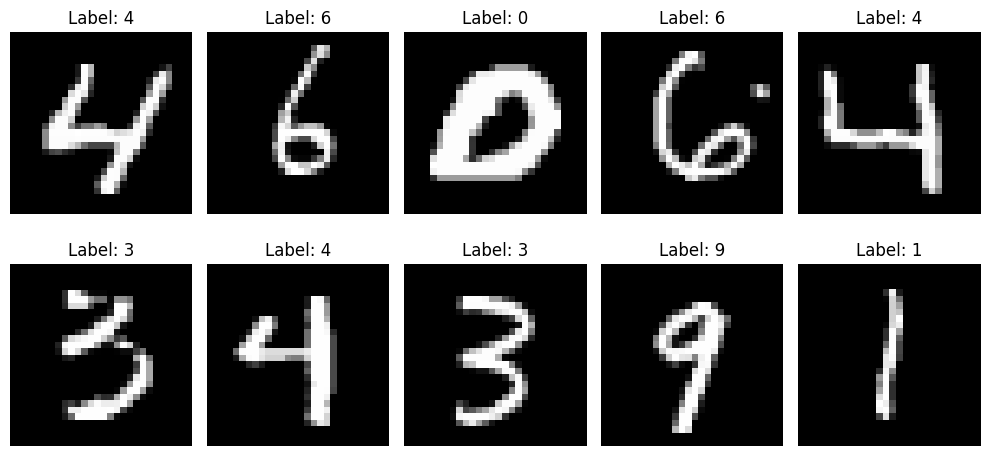

In [6]:
# Show 10 random training examples
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i in range(10):
    idx = np.random.randint(0, len(X_train))
    img = X_train[idx].reshape(28, 28)
    label = np.argmax(y_train[idx])   # convert one-hot back to digit
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [41]:
import numpy as np

def initialize(K, D, D_i, D_o):
    # Set seed for reproducibility (as in lab notebooks)
    np.random.seed(0)

    # Make empty lists for weights (Omega_k) and biases (beta_k)
    all_weights = [None] * (K + 1)
    all_biases = [None] * (K + 1)

    # Handle special case: No hidden layers (K=0), direct input to output
    if K == 0:
        fan_in = D_i
        all_weights[0] = np.random.normal(size=(D_o, D_i)) * np.sqrt(2 / fan_in)
        all_biases[0] = np.zeros((D_o, 1))  # Zeros as per assignment
    else:
        # Input to first hidden layer
        fan_in = D_i
        all_weights[0] = np.random.normal(size=(D, D_i)) * np.sqrt(2 / fan_in)
        all_biases[0] = np.zeros((D, 1))  # Zeros

        # Intermediate hidden layers
        for layer in range(1, K):
            fan_in = D
            all_weights[layer] = np.random.normal(size=(D, D)) * np.sqrt(2 / fan_in)
            all_biases[layer] = np.zeros((D, 1))  # Zeros

        # Last hidden to output layer
        fan_in = D
        all_weights[K] = np.random.normal(size=(D_o, D)) * np.sqrt(2 / fan_in)
        all_biases[K] = np.zeros((D_o, 1))  # Zeros

    return all_weights, all_biases

In [44]:
# Test with lab-like params
K = 5
D = 6
D_i = 1
D_o = 1
all_weights, all_biases = initialize(K, D, D_i, D_o)

# Print shapes to confirm (should match lab notebooks)
for layer in range(K + 1):
     print("Weights shapes:", [W.shape for W in all_weights])
     #print(f"Layer {layer}: Weights shape {all_weights[layer].shape}, Biases shape {all_biases[layer].shape}")

Weights shapes: [(6, 1), (6, 6), (6, 6), (6, 6), (6, 6), (1, 6)]
Weights shapes: [(6, 1), (6, 6), (6, 6), (6, 6), (6, 6), (1, 6)]
Weights shapes: [(6, 1), (6, 6), (6, 6), (6, 6), (6, 6), (1, 6)]
Weights shapes: [(6, 1), (6, 6), (6, 6), (6, 6), (6, 6), (1, 6)]
Weights shapes: [(6, 1), (6, 6), (6, 6), (6, 6), (6, 6), (1, 6)]
Weights shapes: [(6, 1), (6, 6), (6, 6), (6, 6), (6, 6), (1, 6)]


In [46]:
import numpy as np

def sigmoid(z):
    """Sigmoid activation: 1 / (1 + exp(-z))"""
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(z):
    """Derivative of sigmoid w.r.t. its input z"""
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    """ReLU activation: max(0, z)"""
    return np.maximum(0, z)

def relu_derivative(z):
    """Derivative of ReLU w.r.t. its input z"""
    return (z > 0).astype(float)   # 1 where z > 0, 0 otherwise

In [47]:
# Small test
z = np.array([-2, -1, 0, 1, 2])

print("Input z:", z)
print("sigmoid(z):", sigmoid(z))
print("sigmoid'(z):", sigmoid_derivative(z))
print("relu(z):", relu(z))
print("relu'(z):", relu_derivative(z))

Input z: [-2 -1  0  1  2]
sigmoid(z): [0.11920292 0.26894142 0.5        0.73105858 0.88079708]
sigmoid'(z): [0.10499359 0.19661193 0.25       0.19661193 0.10499359]
relu(z): [0 0 0 1 2]
relu'(z): [0. 0. 0. 1. 1.]


In [48]:
def forward_pass(x, all_weights, all_biases, activation=relu):
    """
    Forward pass through the fully connected network.

    Args:
        x:              Input data, shape (batch_size, D_input)
        all_weights:    List of weight matrices [W0, W1, ..., WK]
        all_biases:     List of bias vectors [b0, b1, ..., bK]
        activation:     Activation function to use in hidden layers (default: relu)

    Returns:
        logits:         Output before softmax, shape (batch_size, D_output)
        pre_activations: List of z_k = W_k a_{k-1} + b_k for each layer
        activations:     List of a_k = activation(z_k) for each layer
                         (a_{-1} = x is the input, not stored in the list)
    """
    # We'll store z and a for every layer (including the last one)
    pre_activations = []   # list of z_k
    activations = [x]      # start with input x as activations[0]

    # Start with input as the "activation" of the previous (imaginary) layer
    a = x  # shape: (batch_size, D_i)

    # Go through all layers (0 to K)
    for layer in range(len(all_weights)):
        W = all_weights[layer]     # (out_dim, in_dim)
        b = all_biases[layer]      # (out_dim, 1)

        # Pre-activation: z = a * W^T + b^T  (but careful with shapes)
        # Better: z = x @ W.T + b.T   but since b is (out,1), we broadcast
        z = a @ W.T + b.T          # shape: (batch_size, out_dim)

        # Save pre-activation
        pre_activations.append(z)

        # Apply activation (except possibly on the last layer — we keep logits raw)
        if layer < len(all_weights) - 1:
            a = activation(z)
        else:
            a = z   # no activation on output (logits)

        # Save activation
        activations.append(a)

    # Final output is the last activation (logits)
    logits = activations[-1]

    return logits, pre_activations, activations # activations[0] = x, activations[1:] = hidden + logits

In [49]:
# Reuse the small network you initialized earlier
K = 5
D = 6
D_i = 1
D_o = 1

all_weights, all_biases = initialize(K, D, D_i, D_o)

# Fake batch of 4 samples, each with 1 feature
x_test = np.random.randn(4, 1)   # shape (4, 1)

logits, zs, as_ = forward_pass(x_test, all_weights, all_biases, activation=relu)

print("Logits shape:", logits.shape)          # should be (4, 1)
print("Number of pre-activations:", len(zs))  # should be 6 (layers 0 to 5)
print("Number of activations:", len(as_))     # should be 6
print("First activation shape (after layer 0):", as_[0].shape)  # (4, 6)
print("Last pre-activation shape:", zs[-1].shape)  # (4, 1)

Logits shape: (4, 1)
Number of pre-activations: 6
Number of activations: 7
First activation shape (after layer 0): (4, 1)
Last pre-activation shape: (4, 1)


In [50]:
import numpy as np

def softmax(logits):
    """
    Compute softmax probabilities.
    logits: shape (batch_size, D_output)
    Returns: probabilities, shape (batch_size, D_output), sums to 1 per row
    """
    # Numerical stability: subtract max per sample (broadcasting)
    max_logits = np.max(logits, axis=1, keepdims=True)  # shape (batch_size, 1)
    exp_shifted = np.exp(logits - max_logits)
    sum_exp = np.sum(exp_shifted, axis=1, keepdims=True)
    probs = exp_shifted / sum_exp
    return probs


def compute_cost(logits, y_true):
    """
    Compute average cross-entropy loss.
    logits:  shape (batch_size, D_output)  ← raw output from forward pass
    y_true:  shape (batch_size, D_output)  ← one-hot encoded labels

    Returns: scalar (average loss over the batch)
    """
    batch_size = logits.shape[0]

    # Get predicted probabilities
    probs = softmax(logits)

    # Cross-entropy: - sum (y * log(p)) , averaged over batch
    # We add small epsilon to avoid log(0)
    log_probs = np.log(probs + 1e-15)
    correct_log_probs = y_true * log_probs
    loss_per_sample = -np.sum(correct_log_probs, axis=1)   # shape (batch_size,)

    # Average over batch
    total_loss = np.mean(loss_per_sample)

    return total_loss


def d_cost_d_logits(logits, y_true):
    """
    Derivative of cross-entropy loss w.r.t. logits (pre-softmax values).

    Returns: gradient shape (batch_size, D_output)
    This is exactly what we need for backpropagation from the output layer.
    """
    probs = softmax(logits)
    # Gradient = softmax - one-hot label   (vector form for each sample)
    gradient = probs - y_true
    return gradient

In [51]:
# Small test with 3 samples, 4 classes
logits = np.array([
    [2.0, 1.0, 0.1, -1.0],   # should predict class 0
    [-1.0, 3.0, 0.5, 2.0],   # should predict class 1
    [0.5, -2.0, 4.0, -3.0]   # should predict class 2
])

y_true = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0]
])

probs = softmax(logits)
cost = compute_cost(logits, y_true)
grad = d_cost_d_logits(logits, y_true)

print("Softmax probabilities:\n", np.round(probs, 4))
print("\nCross-entropy loss:", round(cost, 6))
print("\nGradient dL/df (should be probs - y_true):\n", np.round(grad, 4))

Softmax probabilities:
 [[6.381e-01 2.347e-01 9.540e-02 3.180e-02]
 [1.250e-02 6.811e-01 5.590e-02 2.506e-01]
 [2.920e-02 2.400e-03 9.675e-01 9.000e-04]]

Cross-entropy loss: 0.288814

Gradient dL/df (should be probs - y_true):
 [[-0.3619  0.2347  0.0954  0.0318]
 [ 0.0125 -0.3189  0.0559  0.2506]
 [ 0.0292  0.0024 -0.0325  0.0009]]


In [52]:
# Add large constant to logits
logits_shifted = logits + 1000
cost_shifted = compute_cost(logits_shifted, y_true)
print("Original cost:", cost)
print("Cost after adding 1000:", cost_shifted)   # should be almost identical

Original cost: 0.2888136549114925
Cost after adding 1000: 0.2888136549114933


In [61]:
def backward_pass(dL_df, pre_activations, activations, all_weights, activation_derivative=relu_derivative):
    """
    Backward pass: compute gradients for all weights and biases.

    Args:
        dL_df:              Gradient of loss w.r.t. logits, shape (batch_size, D_output)
        pre_activations:    List of z_k for each layer, len = K+1
        activations:        List of a_k for each layer, len = K+1
                            (activations[0] is input x, activations[1] is after first hidden layer, ..., activations[-1] = logits)
        all_weights:        List of weight matrices [W0, W1, ..., WK]
        activation_derivative: derivative function of the hidden activation (default: relu_derivative)

    Returns:
        dL_dweights: list of gradients w.r.t. each weight matrix, same length as all_weights
        dL_dbiases:  list of gradients w.r.t. each bias vector, same length as all_biases
    """
    num_layers = len(all_weights)  # number of layers
    batch_size = dL_df.shape[0]

    dL_dweights = [None] * num_layers
    dL_dbiases  = [None] * num_layers

    # Start from the output layer and go backwards
    # delta is dL/dz for the current layer
    delta = dL_df  # shape (batch_size, D_output)  ← this is dL/dz_K (for the last layer)

    # Loop from the last layer (num_layers - 1) down to the first layer (0)
    for layer in range(num_layers - 1, -1, -1):
        # Current layer quantities
        z = pre_activations[layer]           # z_k, shape (batch_size, out_dim_k)
        a_prev = activations[layer]          # a_{k-1}, shape (batch_size, in_dim_k)

        # For hidden layers (layer < num_layers - 1), the `delta` at this point represents dL/da_k.
        # To get dL/dz_k, we multiply by the derivative of the activation function w.r.t. its input `z_k`.
        if layer < num_layers - 1:
            delta = delta * activation_derivative(z) # element-wise product: (batch_size, out_dim_k)

        # Gradients for biases of the current layer k
        # dL/db_k = mean(dL/dz_k, axis=0)
        dL_dbiases[layer] = np.mean(delta, axis=0, keepdims=True).T   # shape (out_dim_k, 1)

        # Gradients for weights of the current layer k
        # dL/dW_k = (dL/dz_k).T @ a_{k-1}  (transposed because z = a @ W.T + b.T)
        dL_dweights[layer] = (delta.T @ a_prev) / batch_size          # shape (out_dim_k, in_dim_k)

        # Propagate delta backwards to the previous layer (dL/da_{k-1})
        # Only if it's not the first layer (input layer doesn't have preceding weights)
        if layer > 0:
            W = all_weights[layer] # W_k, shape (out_dim_k, in_dim_k)
            # dL/da_{k-1} = (dL/dz_k) @ W_k
            # (batch_size, out_dim_k) @ (out_dim_k, in_dim_k) -> (batch_size, in_dim_k)
            delta = delta @ W

    return dL_dweights, dL_dbiases # Moved outside the loop

In [ ]:
# Assume you have x_train batch, y_train batch, all_weights, all_biases
logits, zs, as_ = forward_pass(x_batch, all_weights, all_biases)
loss = compute_cost(logits, y_batch)
dL_df = d_cost_d_logits(logits, y_batch)

dweights, dbiases = backward_pass(dL_df, zs, as_, all_weights)

print(len(dweights), len(dbiases))          # should be K+1
print(dweights[-1].shape == all_weights[-1].shape)  # True
print(dbiases[-1].shape == all_biases[-1].shape)    # True

In [63]:
def update_parameters(all_weights, all_biases, dL_dweights, dL_dbiases, learning_rate):
    """
    Update all weights and biases using gradient descent.

    Parameters:
        all_weights:     list of weight matrices (Ω_0, Ω_1, ..., Ω_K)
        all_biases:      list of bias vectors (β_0, β_1, ..., β_K)
        dL_dweights:     list of gradients w.r.t. weights (same length as all_weights)
        dL_dbiases:      list of gradients w.r.t. biases (same length as all_biases)
        learning_rate:   scalar α (step size)

    Returns:
        Updated all_weights and all_biases (you can modify in-place or return new lists)
    """
    # Number of layers
    num_layers = len(all_weights)

    # Update each layer
    for layer in range(num_layers):
        # Update weights: W ← W - α * ∇W
        all_weights[layer] = all_weights[layer] - learning_rate * dL_dweights[layer]

        # Update biases: b ← b - α * ∇b
        all_biases[layer] = all_biases[layer] - learning_rate * dL_dbiases[layer]

    # Since we modified the lists in-place, we can just return them
    return all_weights, all_biases

In [ ]:
#### Alternative
def update_parameters(all_weights, all_biases, dL_dweights, dL_dbiases, learning_rate):
    updated_weights = []
    updated_biases = []

    for layer in range(len(all_weights)):
        new_W = all_weights[layer] - learning_rate * dL_dweights[layer]
        new_b = all_biases[layer] - learning_rate * dL_dbiases[layer]

        updated_weights.append(new_W)
        updated_biases.append(new_b)

    return updated_weights, updated_biases

In [ ]:
## Not to be run now
# In a training step:
logits, zs, activations = forward_pass(x_batch, all_weights, all_biases)
loss = compute_cost(logits, y_batch)
dl_df = d_cost_d_logits(logits, y_batch)

dweights, dbiases = backward_pass(dl_df, zs, activations, all_weights)

# Now update
all_weights, all_biases = update_parameters(
    all_weights,
    all_biases,
    dweights,
    dbiases,
    learning_rate=0.01
)


In [64]:
import numpy as np

def predict(X, y, all_weights, all_biases, return_probabilities=False):
    """
    Make predictions on a dataset and compute accuracy + average loss.

    Args:
        X:              Input images, shape (N, 784)
        y:              One-hot labels, shape (N, 10)
        all_weights:    List of weight matrices
        all_biases:     List of bias vectors
        return_probabilities: If True, also return the softmax probabilities

    Returns:
        predictions:    Predicted class indices, shape (N,)
        accuracy:       Fraction of correct predictions (float)
        cost:           Average cross-entropy loss (float)
        probabilities:  (optional) softmax outputs, shape (N, 10)
    """
    # Forward pass on the entire dataset
    logits, _, _ = forward_pass(X, all_weights, all_biases)

    # Get predicted probabilities
    probabilities = softmax(logits)           # shape (N, 10)

    # Predicted class = argmax over classes
    predictions = np.argmax(probabilities, axis=1)   # shape (N,)

    # True class labels (from one-hot)
    true_labels = np.argmax(y, axis=1)               # shape (N,)

    # Accuracy
    correct = (predictions == true_labels)
    accuracy = np.mean(correct)                      # or np.sum(correct) / len(X)

    # Average cross-entropy loss
    cost = compute_cost(logits, y)

    if return_probabilities:
        return predictions, accuracy, cost, probabilities
    else:
        return predictions, accuracy, cost

In [56]:
# After training (or even before, to see random performance)
pred, acc, loss = predict(X_test, y_test, all_weights, all_biases)

print(f"Test accuracy: {acc:.4f}  ({acc*100:.2f}%)")
print(f"Test average loss: {loss:.4f}")

# Or on training set
_, train_acc, train_loss = predict(X_train, y_train, all_weights, all_biases)
print(f"Train accuracy: {train_acc:.4f}, Train loss: {train_loss:.4f}")

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 784)

In [65]:
import numpy as np

def random_mini_batches(X, Y, mini_batch_size=64, shuffle=True):
    """
    Creates a list of random mini-batches from (X, Y)

    Arguments:
    X -- input data, shape (num_examples, input_dim) e.g. (60000, 784)
    Y -- labels (one-hot), shape (num_examples, num_classes) e.g. (60000, 10)
    mini_batch_size -- size of the mini-batches, integer
    shuffle -- whether to shuffle the data before creating mini-batches (usually True)

    Returns:
    mini_batches -- list of tuples: [(x_mini1, y_mini1), (x_mini2, y_mini2), ...]
    """
    m = X.shape[0]  # number of training examples
    mini_batches = []

    # Step 1: Shuffle the data (if shuffle is True)
    if shuffle:
        # Generate random permutation of indices
        permutation = np.random.permutation(m)
        # Shuffle both X and Y using the same permutation
        shuffled_X = X[permutation]
        shuffled_Y = Y[permutation]
    else:
        shuffled_X = X
        shuffled_Y = Y

    # Step 2: Partition into mini-batches
    # Number of complete mini-batches
    num_complete_batches = m // mini_batch_size

    for k in range(num_complete_batches):
        x_mini = shuffled_X[k * mini_batch_size : (k + 1) * mini_batch_size]
        y_mini = shuffled_Y[k * mini_batch_size : (k + 1) * mini_batch_size]
        mini_batches.append((x_mini, y_mini))

    # Step 3: Handle the last (possibly smaller) mini-batch
    if m % mini_batch_size != 0:
        x_mini_last = shuffled_X[num_complete_batches * mini_batch_size :]
        y_mini_last = shuffled_Y[num_complete_batches * mini_batch_size :]
        mini_batches.append((x_mini_last, y_mini_last))

    return mini_batches

In [66]:
# Assuming you already have:
# X_train, y_train, X_test, y_test = load_mnist()

batch_size = 128

# Generate mini-batches for one epoch
mini_batches = random_mini_batches(X_train, y_train, mini_batch_size=batch_size)

print(f"Number of mini-batches: {len(mini_batches)}")
print(f"First mini-batch shapes: X={mini_batches[0][0].shape}, Y={mini_batches[0][1].shape}")

# Check the last one (may be smaller)
print(f"Last mini-batch shapes:  X={mini_batches[-1][0].shape}, Y={mini_batches[-1][1].shape}")

Number of mini-batches: 469
First mini-batch shapes: X=(128, 784), Y=(128, 10)
Last mini-batch shapes:  X=(96, 784), Y=(96, 10)


In [67]:
def train_model(
    X_train, y_train,
    X_test, y_test,
    layer_sizes,                # e.g. [784, 128, 64, 10] — input + hidden + output
    learning_rate=0.01,
    batch_size=128,
    num_epochs=20,
    eval_every=100,             # evaluate every N batches
    random_seed=42
):
    """
    Train a fully connected neural network on MNIST.

    Returns:
        history: dict with keys:
            'train_losses', 'test_losses', 'train_accs', 'test_accs'
            (lists of values collected during training)
    """
    np.random.seed(random_seed)

    # ------------------------------------------------
    # 1. Initialize model
    # ------------------------------------------------
    # layer_sizes = [input_dim, hidden1, hidden2, ..., output_dim]
    # We derive K and D from this list
    input_dim = layer_sizes[0]      # should be 784
    output_dim = layer_sizes[-1]    # should be 10
    hidden_dims = layer_sizes[1:-1] # hidden layer sizes

    K = len(hidden_dims)            # number of hidden layers

    # Create lists of weights and biases
    all_weights, all_biases = [], []

    prev_dim = input_dim
    for dim in hidden_dims + [output_dim]:
        # He initialization for weights
        W = np.random.randn(dim, prev_dim) * np.sqrt(2.0 / prev_dim)
        b = np.zeros((dim, 1))
        all_weights.append(W)
        all_biases.append(b)
        prev_dim = dim

    # ------------------------------------------------
    # 2. Training history
    # ------------------------------------------------
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    global_step = 0  # for eval_every

    print(f"Starting training: {num_epochs} epochs, batch size {batch_size}, lr {learning_rate}")
    print(f"Architecture: {layer_sizes}")

    # ------------------------------------------------
    # 3. Training loop
    # ------------------------------------------------
    for epoch in range(num_epochs):
        # Shuffle and create mini-batches for this epoch
        mini_batches = random_mini_batches(X_train, y_train, batch_size)

        epoch_loss = 0.0
        num_batches = len(mini_batches)

        for i, (x_batch, y_batch) in enumerate(mini_batches):
            global_step += 1

            # Forward
            logits, pre_acts, acts = forward_pass(x_batch, all_weights, all_biases)

            # Loss
            batch_loss = compute_cost(logits, y_batch)
            epoch_loss += batch_loss

            # Backward
            dL_dlogits = d_cost_d_logits(logits, y_batch)
            dweights, dbiases = backward_pass(
                dL_dlogits, pre_acts, acts, all_weights
            )

            # Update
            all_weights, all_biases = update_parameters(
                all_weights, all_biases,
                dweights, dbiases,
                learning_rate=learning_rate
            )

            # Periodic evaluation
            if global_step % eval_every == 0 or i == num_batches - 1:
                # Train set performance
                _, train_acc, train_loss = predict(X_train, y_train, all_weights, all_biases)

                # Test set performance
                _, test_acc, test_loss = predict(X_test, y_test, all_weights, all_biases)

                train_losses.append(train_loss)
                test_losses.append(test_loss)
                train_accs.append(train_acc)
                test_accs.append(test_acc)

                print(f"[Epoch {epoch+1}/{num_epochs} | Step {global_step}] "
                      f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
                      f"Test loss: {test_loss:.4f}  acc: {test_acc:.4f}")

        # End-of-epoch average loss
        avg_epoch_loss = epoch_loss / num_batches
        print(f"Epoch {epoch+1} finished. Avg batch loss: {avg_epoch_loss:.4f}")

    # Return history for plotting
    history = {
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_accs': train_accs,
        'test_accs': test_accs
    }

    return history, all_weights, all_biases

Starting training: 2 epochs, batch size 64, lr 0.001
Architecture: [784, 32, 10]
[Epoch 1/2 | Step 50] Train loss: 2.3302  acc: 0.1328 | Test loss: 2.3323  acc: 0.1304
[Epoch 1/2 | Step 100] Train loss: 2.2700  acc: 0.1610 | Test loss: 2.2706  acc: 0.1579
[Epoch 1/2 | Step 150] Train loss: 2.2242  acc: 0.1877 | Test loss: 2.2235  acc: 0.1845
[Epoch 1/2 | Step 200] Train loss: 2.1834  acc: 0.2191 | Test loss: 2.1817  acc: 0.2167
[Epoch 1/2 | Step 250] Train loss: 2.1462  acc: 0.2530 | Test loss: 2.1436  acc: 0.2494
[Epoch 1/2 | Step 300] Train loss: 2.1106  acc: 0.2846 | Test loss: 2.1071  acc: 0.2804
[Epoch 1/2 | Step 350] Train loss: 2.0759  acc: 0.3170 | Test loss: 2.0716  acc: 0.3120
[Epoch 1/2 | Step 400] Train loss: 2.0413  acc: 0.3444 | Test loss: 2.0361  acc: 0.3409
[Epoch 1/2 | Step 450] Train loss: 2.0066  acc: 0.3713 | Test loss: 2.0008  acc: 0.3679
[Epoch 1/2 | Step 500] Train loss: 1.9711  acc: 0.4013 | Test loss: 1.9647  acc: 0.4029
[Epoch 1/2 | Step 550] Train loss: 1.936

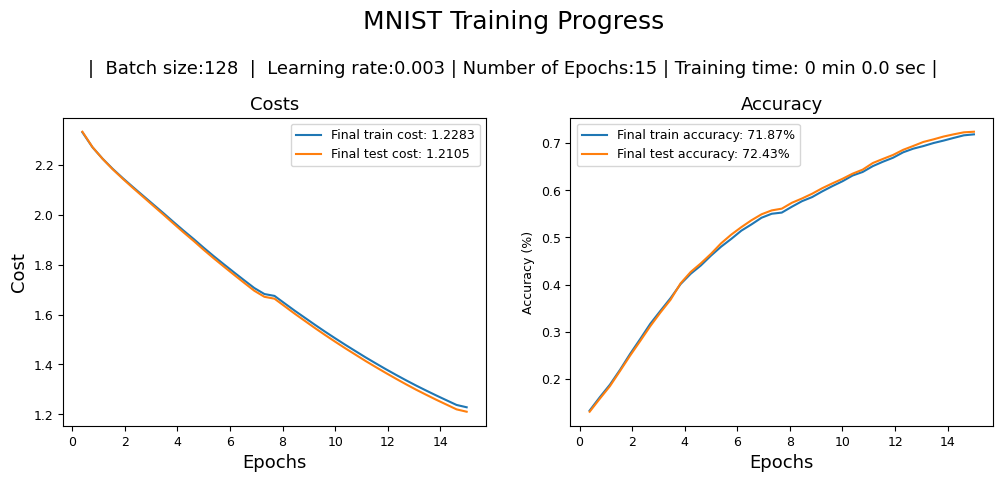

In [68]:
# Example call
history, final_weights, final_biases = train_model(
    X_train, y_train,
    X_test, y_test,
    layer_sizes=[784, 32, 10],  # Small network for quick test (1 hidden layer, 32 units)
    learning_rate=0.001,
    batch_size=64,
    num_epochs=2,  # Short run
    eval_every=50
)

# Plot results (using the provided function)
from utils import training_curve_plot

training_curve_plot(
    title="MNIST Training Progress",
    train_costs=history['train_losses'],
    test_costs=history['test_losses'],
    train_accuracy=history['train_accs'],
    test_accuracy=history['test_accs'],
    batch_size=128,
    learning_rate=0.003,
    num_epochs=15,
    elapsed=0  # you can measure time if you want
)